## Earthdata GIS OPERA DSWx-HLS Science Use Case: Analyzing Surface Water Extent Change at Lake Mead
<br>

Authored by Brandi Downs, Nicholas Tarpinian, Catalina Taglialatela (NASA PO.DAAC)

_Created: 2026-06-05_ <br>
_Last Updated: 2026-06-29_ <br>



## Summary

This guide shows how to use Python to access the OPERA DSWx-HLS Image Service from the NASA [**Earthdata GIS (EGIS)**](https://gis.earthdata.nasa.gov/portal/home/index.html) REST API and perform a surface water time series analysis. This EGIS service allows users to interactively explore and visualize OPERA DSWx-HLS data directly from the Image Service without having to download and manage data files locally.

Using Lake Mead, USA, as an example, the notebook demonstrates how to query and export OPERA DSWx-HLS observations (specifically the `B01_WTR` layer) for a user-defined area of interest, mosaic multiple image tiles acquired on the same date, remove mosaics containing excessive fill values and cloud coverage, and calculate changes in open water extent through time. The workflow concludes by analyzing seasonal and long-term trends to quantify temporal changes in water extent and demonstrate how OPERA DSWx-HLS can be used to monitor evolving hydrologic conditions.

For an introductory tutorial on accessing OPERA DSWx-HLS data through the EGIS REST API using Python, see:<br>
[Earthdata GIS OPERA DSWx-HLS Image Service Access - Programmatic](OPERA_EGIS_access_Python.ipynb)

For more details on these services and the latest available services, please visit the [EGIS OPERA Image Service page](https://gis.earthdata.nasa.gov/portal/home/group.html?id=780767a6cee24331baae8557c78d2e8a#overview).<br>
For more details on the `B01_WTR` layer available through NASA EGIS, please see [OPERA_L3_DSWX-HLS_V1_B01_WTR](https://gis.earthdata.nasa.gov/portal/home/item.html?id=59caecb96b5b42dd85aa3001a10f7786).

### Learning Objectives
- **Programmatic Access:** Connect to and interact with the OPERA DSWx-HLS REST Image Service API from EGIS using Python.
- **User Configuration:** Define your geographic area of interest, time range, and data fields.
- **Time Series Generation:** Export, mosaic, and organize OPERA DSWx-HLS observations into a consistent time series of raster arrays.
- **Open Water Analysis:** Calculate open water extent for each observation and generate a time series of surface water area.
- **Trend Analysis and Visualization:** Visualize temporal changes in open water extent and evaluate seasonal and long-term trends using statistical smoothing and linear regression.

### Memory Requirements
At the time of writing, this workflow exports and processes more than three years of OPERA DSWx-HLS observations for the example area of interest. During processing, the notebook may require more than 4 GB of RAM, and this requirement will continue to increase as additional OPERA DSWx-HLS observations become available. Systems with insufficient available memory may experience significantly slower performance or cause the Jupyter kernel to terminate. If this occurs, consider reducing the date range or using a smaller area of interest.

However, note that the time series and trend analyses later in this notebook are intended for longer observational records. Reducing the date range—particularly to less than one year—may limit the usefulness of those analyses.

## Step 1: Set Up the Environment

In this section, we import the required Python packages, define helper functions used throughout the notebook, and configure the HTTP requests needed to interact with the OPERA DSWx-HLS Image Service through the Earthdata GIS (EGIS) REST API.

In [1]:
# First, check that all required packages are installed

import importlib

required_packages = {
    "requests": "requests",
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "PIL": "Pillow",
    "pyproj": "pyproj",
    "rasterio": "rasterio",
    "statsmodels": "statsmodels",
    "psutil": "psutil"
}

missing = []
for module, package in required_packages.items():
    try:
        importlib.import_module(module)
    except ImportError:
        missing.append(package)

if missing:
    print("The following required packages are not installed:\n")
    for pkg in missing:
        print(f"  - {pkg}")
    packages = " ".join(missing)
    print("\nInstall the missing packages using your preferred package manager.\n")
    print("Conda:")
    print(f"    conda install -c conda-forge {packages}\n")
    print("Pip:")
    print(f"    pip install {packages}")
else:
    print("✓ All required packages are installed.")

✓ All required packages are installed.


In [2]:
# Import Python packages

import requests
import pandas as pd
import time
import numpy as np
from rasterio.io import MemoryFile
from pyproj import Transformer
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import datetime
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from statsmodels.nonparametric.smoothers_lowess import lowess
import os
import psutil

### Note

The Image Service limits the execution time of individual export requests to **1200 seconds (20 minutes)**. In this notebook, export and download requests are given a shorter client-side timeout of **120 seconds (2 minutes)** to prevent very large or stalled requests from running too long. This notebook exports each date separately, which helps avoid long-running requests. However, very large areas of interest or periods of high server demand may still cause an individual request to exceed the notebook timeout. If this occurs, consider reducing the geographic extent or increasing the export pixel size before rerunning the notebook.

In [3]:
# Image Service URL
URL = "https://gis.earthdata.nasa.gov/image/rest/services/C2617126679-POCLOUD/OPERA_L3_DSWX-HLS_V1_B01_WTR/ImageServer"

# Persistent session
SESSION = requests.Session()


def to_epoch_ms(date_str):
    """Convert a date string to Unix epoch milliseconds expected by ArcGIS ImageServer for time queries."""
    return int(pd.Timestamp(date_str, tz="UTC").timestamp() * 1000)


def get_json(url, params=None):
    """Send a GET request and return JSON response."""
    p = dict(params or {})
    p.setdefault("f", "json")
    r = SESSION.get(url, params=p, timeout=120)
    r.raise_for_status()
    data = r.json()
    if "error" in data:
        raise RuntimeError(f"Server Error: {data['error']}")
    return data


def query_all_features(url, params, page_size=1000):
    """Query all records from an ArcGIS REST endpoint using pagination.
    This function keeps requesting more records until all matching records are retrieved."""
    all_features = []
    offset = 0
    while True:
        p = dict(params)
        p["resultOffset"] = offset
        p["resultRecordCount"] = page_size
        data = get_json(url, params=p)
        features = data.get("features", [])
        all_features.extend(features)
        exceeded = data.get("exceededTransferLimit", False)
        if not exceeded or len(features) == 0:
            break
        offset += len(features)
    print(f"\nRetrieved {len(all_features)} total records.")
    return all_features


def get_utm_epsg_from_bbox(bbox):
    """
    Choose a UTM EPSG code based on the center of AOI lon/lat bounding box.
    bbox should be xmin,ymin,xmax,ymax in EPSG:4326.
    """
    xmin, ymin, xmax, ymax = map(float, bbox.split(","))
    center_lon = (xmin + xmax) / 2
    center_lat = (ymin + ymax) / 2
    utm_zone = int((center_lon + 180) // 6) + 1
    if center_lat >= 0:
        epsg = 32600 + utm_zone
    else:
        epsg = 32700 + utm_zone
    return epsg


def export_date_mosaic_array(date, url, analysis_bbox, analysis_epsg, width, height, output_format="tiff"):
    """
    Export one mosaicked raster for a single date over the AOI.
    This makes one ImageServer export request per date.
    """
    start = pd.Timestamp(date, tz="UTC")
    end = start + pd.Timedelta(days=1)
    img_params = {
        "bbox": analysis_bbox,
        "bboxSR": str(analysis_epsg),
        "imageSR": str(analysis_epsg),
        "size": f"{width},{height}",
        "format": output_format,
        "adjustAspectRatio": "false",
        "time": f"{int(start.timestamp() * 1000)},{int(end.timestamp() * 1000)}",
        "f": "json",
        "pixelType": "U8",
        "noData": 255,
        "interpolation": "RSP_NearestNeighbor",
    }
    export_info = get_json(f"{url}/exportImage", params=img_params)
    r = SESSION.get(export_info["href"], timeout=120)
    r.raise_for_status()
    with MemoryFile(r.content) as memfile:
        with memfile.open() as src:
            arr = src.read(1)
            transform = src.transform
            crs = src.crs
            nodata = src.nodata
    return date, arr.astype(np.uint8), transform, crs, nodata


def make_export_tiles(x_min, y_min, x_max, y_max, pixel_size_m, max_w, max_h):
    """
    Split projected AOI bbox into smaller tiles that stay within ImageServer max size. This preserves the
    native (30 m) resolution instead of downsampling images that are larger than the ImageServer max size.
    """
    tile_width_m = max_w * pixel_size_m
    tile_height_m = max_h * pixel_size_m
    tiles = []
    y0 = y_min
    while y0 < y_max:
        y1 = min(y0 + tile_height_m, y_max)
        x0 = x_min
        while x0 < x_max:
            x1 = min(x0 + tile_width_m, x_max)
            width = int(np.ceil((x1 - x0) / pixel_size_m))
            height = int(np.ceil((y1 - y0) / pixel_size_m))
            tiles.append({
                "bbox": f"{x0},{y0},{x1},{y1}",
                "x_min": x0,
                "y_min": y0,
                "x_max": x1,
                "y_max": y1,
                "width": width,
                "height": height
            })
            x0 = x1
        y0 = y1
    return tiles


def export_date_mosaic_tiled_array(date, url, export_tiles, analysis_epsg, full_width, full_height, x_min, y_max, pixel_size_m, 
                                   output_format="tiff"):
    """
    Loop through the tiles for a given date, export each tile, and stitch them back together into one full raster array.
    Each tile stays within maxImageWidth/maxImageHeight.
    """
    full_arr = np.full((full_height, full_width), 255, dtype=np.uint8)
    output_crs = None
    for tile in export_tiles:
        date_out, tile_arr, transform, crs, nodata = export_date_mosaic_array(
            date=date,
            url=url,
            analysis_bbox=tile["bbox"],
            analysis_epsg=analysis_epsg,
            width=tile["width"],
            height=tile["height"],
            output_format=output_format
        )
        if nodata is not None:
            tile_arr[tile_arr == nodata] = 255
        col0 = int(round((tile["x_min"] - x_min) / pixel_size_m))
        row0 = int(round((y_max - tile["y_max"]) / pixel_size_m))
        row1 = row0 + tile_arr.shape[0]
        col1 = col0 + tile_arr.shape[1]
        full_arr[row0:row1, col0:col1] = tile_arr
        output_crs = crs
    return date, full_arr, output_crs


def print_memory_usage():
    """Print the current RAM usage of the Python process."""
    process = psutil.Process(os.getpid())
    mem = process.memory_info().rss / 1024**3  # GB
    return f"RAM usage: {mem:.1f} GB"


meta = get_json(URL)
max_h = meta.get('maxImageHeight')
max_w = meta.get('maxImageWidth')

print("OPERA DSWx-HLS Image Service ready to query.")

OPERA DSWx-HLS Image Service ready to query.


## Step 2: Query and Export OPERA DSWx-HLS Data

In this section, we define the analysis parameters for the Lake Mead example, including the area of interest, date range, cloud coverage threshold, output fields, and export resolution. The notebook then queries the OPERA DSWx-HLS Image Service for matching observations, exports the data for each available date, mosaics multiple tiles acquired on the same date, and stores the resulting raster arrays for time series analysis.

For this example, we retrieve all available observations regardless of cloud coverage by setting `MAX_CLOUD_COVERAGE` to `100`. Observations with cloud cover are filtered later in the workflow. Reducing this threshold can decrease the number of exported scenes, resulting in faster execution and lower memory usage.

### Notes
- `START_DATE` is inclusive whereas `END_DATE` is exclusive. Data are retrieved over the interval `[START_DATE, END_DATE)`.
- To view all available metadata fields that can be requested from the Image Service using the `FIELDS` variable, run the optional cell below.

In [4]:
# OPTIONAL: Print all available metadata fields
fields = [f.get('name') for f in meta.get('fields', [])]
print(fields)

['objectid', 'name', 'minps', 'maxps', 'lowps', 'highps', 'category', 'centerx', 'centery', 'shape', 'processingdate', 'tileid', 'datetime', 'productgenerationdatetime', 'cloud_coverage', 'spacecraft_name', 'downloadurl', 'urldisplay']


### A Note on Parallel Processing

To reduce overall runtime, this notebook uses Python's `ThreadPoolExecutor` to export multiple acquisition dates concurrently. By default, up to four dates are processed simultaneously (`max_workers = 4`), although the optimal value depends on your available CPU resources, internet connection, and Image Service load.

Increasing `max_workers` may reduce execution time by submitting more export requests in parallel, but it can also increase system resource usage and place additional load on the Image Service. Decreasing `max_workers` will reduce the number of concurrent requests but may increase the total runtime.

In [5]:
# Define Area of Interest (xmin, ymin, xmax, ymax)
# For this example, we are using Lake Mead, USA
BBOX = "-114.86,35.97,-114.02,36.47"

# Define Date Range (YYYY-MM-DD)
START_DATE = "2023-01-01"   # inclusive
END_DATE = pd.Timestamp.utcnow().strftime("%Y-%m-%d")   # gets today's date; exclusive

# Define maximum acceptable cloud coverage (%)
MAX_CLOUD_COVERAGE = 100

# Define specific fields to request from the Image Service
FIELDS = "objectid,name,datetime,cloud_coverage,tileid,spacecraft_name,downloadurl"

# DSWx-HLS fill / nodata value
NODATA = 255

# OPERA DSWx-HLS native pixel size is 30 m.
PIXEL_SIZE_M = 30

print("Querying the OPERA DSWx-HLS Catalog...")

t0 = time.perf_counter()

# Query ImageServer catalog records
query_params = {
    "geometry": BBOX,
    "geometryType": "esriGeometryEnvelope",
    "spatialRel": "esriSpatialRelIntersects",
    "inSR": "4326",
    "where": f"cloud_coverage <= {MAX_CLOUD_COVERAGE}",
    "time": f"{to_epoch_ms(START_DATE)},{to_epoch_ms(END_DATE)}",
    "outFields": FIELDS,
    "returnGeometry": "false",
    "orderByFields": "datetime ASC",
    "resultRecordCount": 1000
}

features = query_all_features(f"{URL}/query", query_params)

if not features:
    print("No scenes found. Try expanding your date range, bounding box, or cloud coverage tolerance.")

else:
    df = pd.DataFrame([f["attributes"] for f in features])
    df["datetime"] = pd.to_datetime(df["datetime"], unit="ms")
    df["date"] = df["datetime"].dt.date
    unique_dates = sorted(df["date"].unique())
    print(f"Found {len(df)} scene records.")
    print(f"Found {len(unique_dates)} unique dates.")

    # Automatically choose an analysis CRS from the AOI
    ANALYSIS_EPSG = get_utm_epsg_from_bbox(BBOX)
    print(f"Using EPSG:{ANALYSIS_EPSG} for analysis.")

    # Convert AOI bbox to analysis CRS and define export size
    xmin, ymin, xmax, ymax = map(float, BBOX.split(","))
    transformer = Transformer.from_crs("EPSG:4326",f"EPSG:{ANALYSIS_EPSG}",always_xy=True)

    # Transform all four corners for a safer projected bounding box
    corners_lon = [xmin, xmin, xmax, xmax]
    corners_lat = [ymin, ymax, ymin, ymax]
    xs_corners, ys_corners = transformer.transform(corners_lon, corners_lat)
    x_min = min(xs_corners)
    x_max = max(xs_corners)
    y_min = min(ys_corners)
    y_max = max(ys_corners)
    full_width = int(np.ceil((x_max - x_min) / PIXEL_SIZE_M))
    full_height = int(np.ceil((y_max - y_min) / PIXEL_SIZE_M))
    print(f"Requested full-resolution export width: {full_width}, height: {full_height}")
    export_tiles = make_export_tiles(
        x_min=x_min,
        y_min=y_min,
        x_max=x_max,
        y_max=y_max,
        pixel_size_m=PIXEL_SIZE_M,
        max_w=max_w,
        max_h=max_h
    )
    print(f"Using {len(export_tiles)} export tile(s) to preserve {PIXEL_SIZE_M} m resolution.")

    # Build one mosaicked raster per date
    dates = []
    values = []  # list of 2D raster arrays, one per date
    x_coords = None
    y_coords = None
    output_transform = None
    output_crs = None

    # Process multiple dates in parallel using worker threads
    # If max_workers=4, up to 4 dates can be exported simultaneously
    max_workers = 4
    removed_nodata_count = 0
    
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        
        # Submit one export task per date. executor.submit() immediately returns a Future object,
        # which acts as a placeholder for the result while the export runs in the background.
        # Build a dictionary that maps each Future back to its corresponding date
        # so we can identify which date completed when the result is returned.
        future_to_date = {
            executor.submit(
                export_date_mosaic_tiled_array,
                date,
                URL,
                export_tiles,
                ANALYSIS_EPSG,
                full_width,
                full_height,
                x_min,
                y_max,
                PIXEL_SIZE_M,
                "tiff"
            ): date
            for date in unique_dates
        }

        # Process completed exports as they finish. as_completed() returns Futures in 
        # completion order, which may differ from the chronological order of unique_dates.
        for i, future in enumerate(as_completed(future_to_date), start=1):
            
            # Retrieve the date associated with this completed export.
            date = future_to_date[future]
            
            try:
                # Retrieve the export result from the completed Future.
                date, arr, crs = future.result()
            except Exception as e:
                # Skip dates whose export failed without stopping the entire run.
                print(f"\nSkipping {date}: export failed")
                print(e)
                continue
                
            # Remove exports that contain only nodata values, indicating no valid pixels were found within the AOI.
            if np.all(arr == NODATA):
                removed_nodata_count += 1
                continue
                
            # Create coordinate vectors once using a common output grid.
            if x_coords is None or y_coords is None:
                x_coords = x_min + (np.arange(full_width) + 0.5) * PIXEL_SIZE_M
                y_coords = y_max - (np.arange(full_height) + 0.5) * PIXEL_SIZE_M
                output_crs = crs
                
            # Store the date and corresponding raster array.
            dates.append(date)
            values.append(arr)

            print(f"Processing completed for {i}/{len(unique_dates)}: {date}. {print_memory_usage()}", end="\r")
            
    if dates:
        # Results were collected in completion order. Sort by date while keeping each raster array paired with its corresponding date.
        results = sorted(zip(dates, values), key=lambda x: x[0]) 
        dates = [r[0] for r in results]
        values = [r[1] for r in results]

    print("\n")
    print("-" * 60, "\n")
    print(f"Removed {removed_nodata_count} dates containing only nodata pixels.")
    print(f"Stored mosaicked raster arrays for {len(dates)} dates.")
    print(f"x coordinate shape: {x_coords.shape if x_coords is not None else 'N/A'}")
    print(f"y coordinate shape: {y_coords.shape if y_coords is not None else 'N/A'}")
    print(f"Output CRS: {output_crs}")
    print(f"Total {print_memory_usage()}")
    print(f"Total runtime: {(time.perf_counter() - t0)/60:.1f} minutes")

Querying the OPERA DSWx-HLS Catalog...

Retrieved 4032 total records.
Found 4032 scene records.
Found 838 unique dates.
Using EPSG:32611 for analysis.
Requested full-resolution export width: 2567, height: 1916
Using 2 export tile(s) to preserve 30 m resolution.
Processing completed for 838/838: 2026-06-23. RAM usage: 4.1 GB

------------------------------------------------------------ 

Removed 456 dates containing only nodata pixels.
Stored mosaicked raster arrays for 382 dates.
x coordinate shape: (2567,)
y coordinate shape: (1916,)
Output CRS: EPSG:32611
Total RAM usage: 4.1 GB
Total runtime: 11.8 minutes


## Step 3: Visualize the Exported Mosaics

Before proceeding with the time series analysis, we visualize a subset of the exported DSWx-HLS mosaics to verify that the data were retrieved successfully and to gain an initial understanding of the surface water conditions observed throughout the study period.

The mosaics are displayed using the projected analysis coordinate reference system (CRS) rather than latitude and longitude. Working in a projected CRS preserves the native 30-meter pixel spacing and enables accurate area calculations later in the workflow. For ease of interpretation, the axis labels are shown in approximate latitude and longitude by transforming the projected tick locations. These lat/lon labels are intended for visual reference only and do not represent a true geographic reprojection of the imagery.

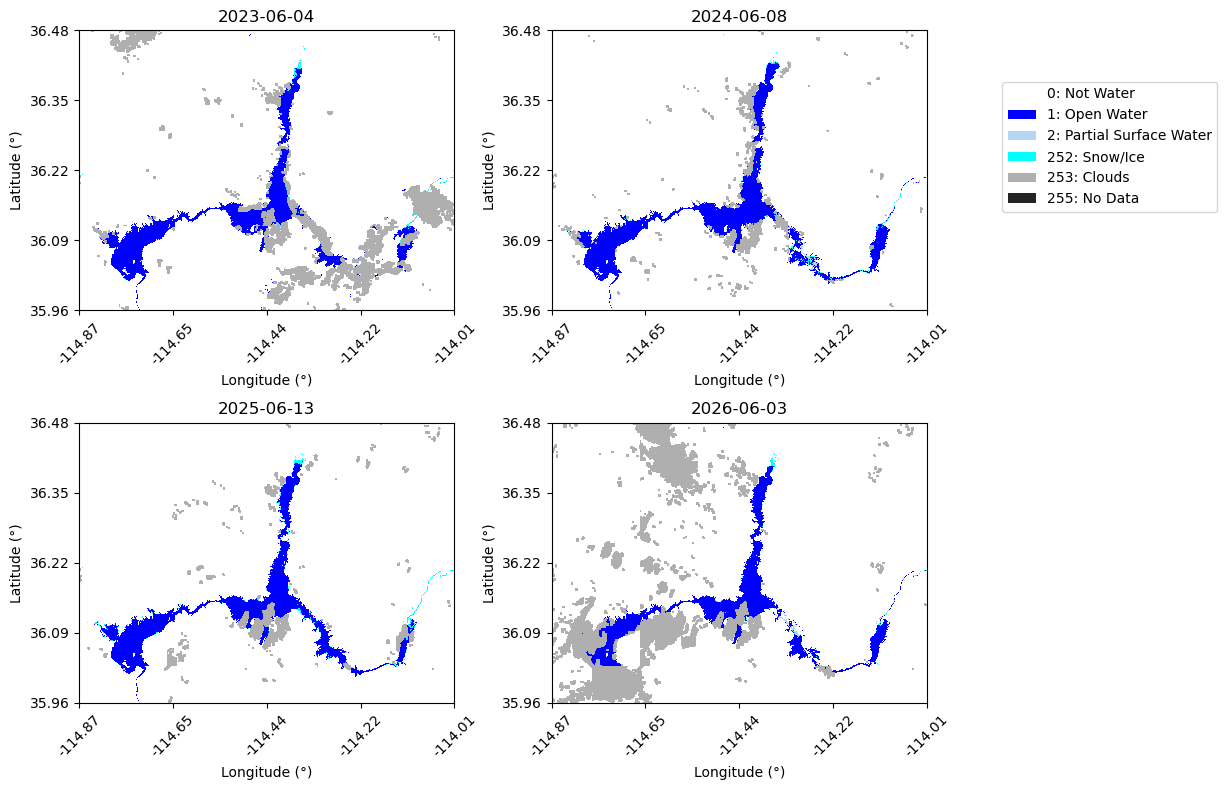

In [6]:
# Plot a few mosaics to explore the data

# Select dates to plot
date_str = ["2023-06-04", "2024-06-08", "2025-06-13", "2026-06-03"]
target_date = [datetime.strptime(x, "%Y-%m-%d").date() for x in date_str]
plot_indices = []
for d in target_date:
    plot_indices.append(dates.index(d))


# DSWx class colors
col_notwater = "#ffffff"    # 0 (not water)
col_openwater = "#0000ff"   # 1 (open water)
col_psw = "#b4d5f4"         # 2 (partial surface water)
col_snowice = "#00ffff"     # 252 (snow/ice)
col_clouds = "#afafaf"      # 253 (clouds)
col_nodata = "#242424"      # 255 (no data)
cmap = ListedColormap([
    col_notwater,   
    col_openwater,   
    col_psw,   
    col_snowice,   
    col_clouds,   
    col_nodata    
])

# Plot DSWx arrays
n = len(plot_indices)
ncols = 2
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(12, 4 * nrows),
    squeeze=False
)
axes = axes.ravel()

# Plot coordinates in lat/lon
to_latlon = Transformer.from_crs(
    f"EPSG:{ANALYSIS_EPSG}",
    "EPSG:4326",
    always_xy=True
)

for ax, idx in zip(axes, plot_indices):

    if idx >= len(dates):
        ax.set_title(f"Index {idx}\nout of range")
        ax.axis("off")
        continue

    arr = values[idx]
    
    plot_arr = np.full(arr.shape, 5, dtype=np.uint8) 
    plot_arr[arr == 0] = 0
    plot_arr[arr == 1] = 1
    plot_arr[arr == 2] = 2
    plot_arr[arr == 252] = 3
    plot_arr[arr == 253] = 4
    plot_arr[arr == 255] = 5

    im = ax.imshow(
        plot_arr,
        cmap=cmap,
        vmin=0,
        vmax=6,
        interpolation="none",
        extent=[
            x_coords.min(),
            x_coords.max(),
            y_coords.min(),
            y_coords.max()
        ],
        origin="upper"
    )

    ax.set_title(f"{dates[idx]}")
    
    # Convert x tick positions to lat/lon
    xticks = np.linspace(x_coords.min(), x_coords.max(), 5)
    yticks = np.linspace(y_coords.min(), y_coords.max(), 5)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)
    lat_labels = [
        f"{to_latlon.transform(x_coords.mean(), y)[1]:.2f}"
        for y in yticks
    ]
    lon_labels = [
        f"{to_latlon.transform(x, y_coords.mean())[0]:.2f}"
        for x in xticks
    ]
    
    ax.set_xticklabels(lon_labels, rotation=45)
    ax.set_yticklabels(lat_labels)
    ax.set_xlabel("Longitude (°)")
    ax.set_ylabel("Latitude (°)")

legend_elements = [
    Patch(facecolor=col_notwater, label="0: Not Water"),
    Patch(facecolor=col_openwater, label="1: Open Water"),
    Patch(facecolor=col_psw, label="2: Partial Surface Water"),
    Patch(facecolor=col_snowice, label="252: Snow/Ice"),
    Patch(facecolor=col_clouds, label="253: Clouds"),
    Patch(facecolor=col_nodata, label="255: No Data"),
]

fig.legend(
    handles=legend_elements,
    loc="upper right",
    bbox_to_anchor=(1.02, 0.9)
)

plt.tight_layout(rect=[0, 0, 0.8, 1])
plt.show()

## Step 4: Filter Mosaics Before Analysis 

Before moving to the time series analysis, we will remove mosaics that may adversely affect the analysis. First, mosaics containing excessive nodata pixels are excluded because they do not provide sufficient valid observations over the area of interest. We then calculate open water extent and cloud coverage for the remaining mosaics, allowing us to identify and remove observations with excessive cloud cover before constructing the final time series.

In [7]:
# Remove mosaics containing excessive nodata pixels

# Maximum allowable number of nodata pixels in a mosaic.
# Mosaics exceeding this threshold are excluded from subsequent analysis.
MAX_NODATA_PIXELS = 1000

# Total number of pixels in each mosaic (all mosaics share the same dimensions).
num_px = values[0].size 

print(
    f"Filtering out mosaics containing more than {MAX_NODATA_PIXELS} nodata pixels "
    f"({100 * MAX_NODATA_PIXELS / num_px:.2f}% of the image)."
)

# Count the number of nodata pixels in each mosaic.
nodata_values = {}
for d,v in zip(dates, values):
    count = np.sum(v==NODATA)
    nodata_values[d] = count

# Retain only mosaics with acceptable nodata coverage.
filtered = [
    (d, v)
    for d, v in zip(dates, values)
    if nodata_values[d] <= MAX_NODATA_PIXELS
]
dates_filtered = [d for d, v in filtered]
values_filtered = [v for d, v in filtered]

print(f"Number of original dates before filtering: {len(dates)}")
print(f"Number of dates after filtering: {len(dates_filtered)}")

Filtering out mosaics containing more than 1000 nodata pixels (0.02% of the image).
Number of original dates before filtering: 382
Number of dates after filtering: 245


In [8]:
# Count open water and cloud pixels for each mosaicked raster
# after removing mosaics with excessive nodata.

nwater = []       # number of open water pixels
ncloud = []       # number of cloud pixels
ncloud_pct = []   # percent cloud cover
water_km2 = []    # open water area (km2)

for v in values_filtered:
    nw = np.sum(v == 1)    # count pixels classified as open water (class 1)
    nc = np.sum(v == 253)  # count pixels classified as clouds (class 253)
    nwater.append(nw)
    ncloud.append(nc)
    ncloud_pct.append(100*nc/num_px)           # calculate cloud cover percentage
    water_km2.append(nw*PIXEL_SIZE_M**2/1e6)   # calculate water area in square km


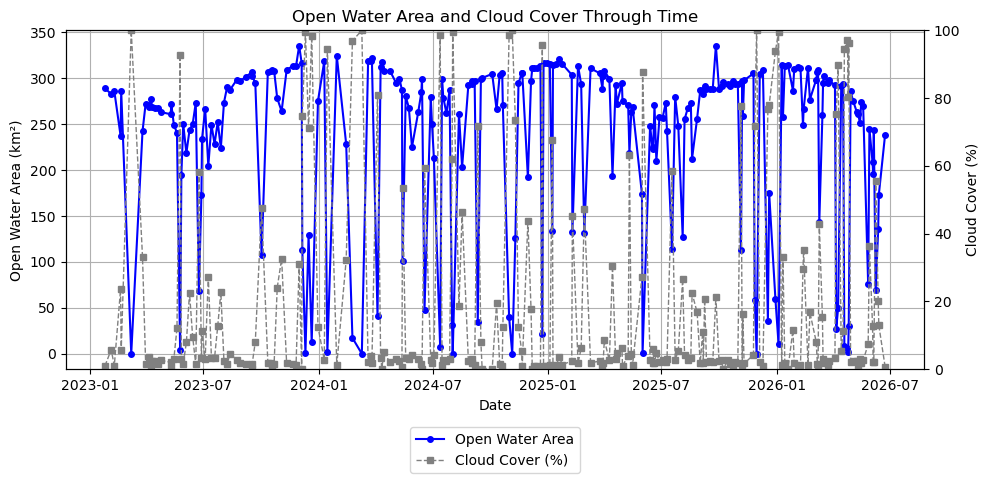

In [9]:
# Plot open water area and cloud percentage through time

fig, ax1 = plt.subplots(figsize=(10, 5))

# Water area
ax1.plot(
    dates_filtered,
    water_km2,
    marker="o",
    markersize=4,
    linewidth=1.5,
    label="Open Water Area",
    color="blue"
)
ax1.set_xlabel("Date")
ax1.set_ylabel("Open Water Area (km²)")
ax1.grid(True)

# Clouds
ax2 = ax1.twinx()
ax2.plot(
    dates_filtered,
    ncloud_pct,
    marker="s",
    markersize=4,
    linewidth=1,
    linestyle="--",
    label="Cloud Cover (%)",
    color="gray"
)
ax2.set_ylim(0, 100)
ax2.set_ylabel("Cloud Cover (%)")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper center", bbox_to_anchor=(0.5, -0.15))

plt.title("Open Water Area and Cloud Cover Through Time")
plt.tight_layout()
plt.show()

The plot above provides an initial view of changes in Lake Mead's surface water extent through time. While seasonal patterns are already apparent, several sharp decreases in open water area coincide with periods of high cloud cover. These decreases are likely caused by clouds obscuring the water surface rather than true reductions in lake extent. In the next step, we filter out mosaics with excessive cloud cover to produce a more reliable time series for trend analysis.

In [10]:
# Filter out mosaics with excessive cloud coverage

# Maximum allowable cloud cover percentage in a mosaic.
# Mosaics exceeding this threshold are excluded from the time series analysis.
MAX_CLOUD_PERCENT = 10

filtered = [
    (d, v)
    for d, v, cp in zip(dates_filtered, values_filtered, ncloud_pct)
    if cp <= MAX_CLOUD_PERCENT
]

dates_cloud_filtered = [d for d, v in filtered]
values_cloud_filtered = [v for d, v in filtered]

print(f"Number of dates before cloud filtering: {len(dates_filtered)}")
print(f"Number of dates after filtering with <= {MAX_CLOUD_PERCENT}% cloud cover: {len(dates_cloud_filtered)}")


# Get updated count of cloud and water pixels per mosaicked raster after filtering by cloud percentage
nwater_f = []       # number of open water pixels
ncloud_f = []       # number of cloud pixels
ncloud_pct_f = []   # percent cloud cover
water_km2_f = []    # open water area (km2)

for v in values_cloud_filtered:
    nw = np.sum(v == 1)    # count pixels classified as open water (class 1)
    nc = np.sum(v == 253)  # count pixels classified as clouds (class 253)
    nwater_f.append(nw)
    ncloud_f.append(nc)
    ncloud_pct_f.append(100*nc/num_px)           # calculate cloud cover percentage
    water_km2_f.append(nw*PIXEL_SIZE_M**2/1e6)   # calculate water area in square km
    

Number of dates before cloud filtering: 245
Number of dates after filtering with <= 10% cloud cover: 162


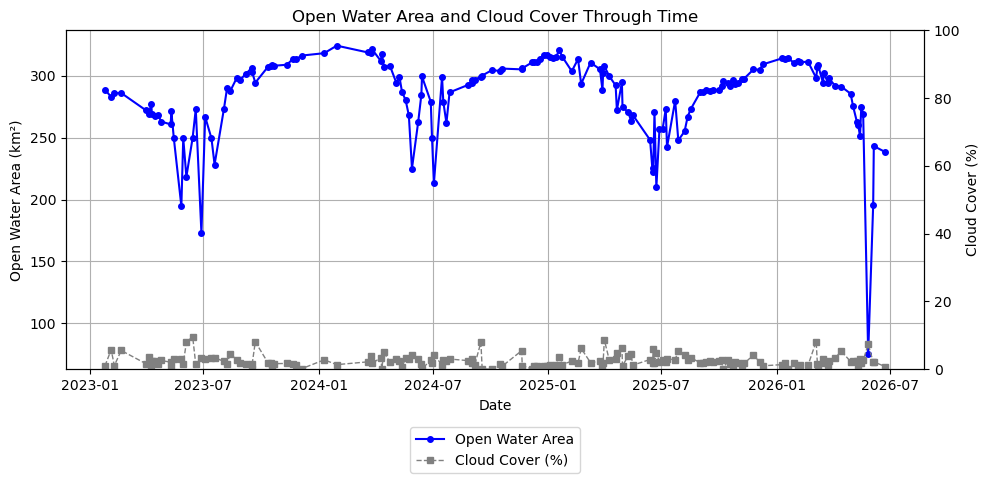

In [11]:
# Plot open water area and cloud percentage through time after filtering for cloud cover

fig, ax1 = plt.subplots(figsize=(10, 5))

# Water area
ax1.plot(
    dates_cloud_filtered,
    water_km2_f,
    marker="o",
    markersize=4,
    linewidth=1.5,
    label="Open Water Area",
    color="blue"
)
ax1.set_xlabel("Date")
ax1.set_ylabel("Open Water Area (km²)")
ax1.grid(True)

# Clouds
ax2 = ax1.twinx()
ax2.plot(
    dates_cloud_filtered,
    ncloud_pct_f,
    marker="s",
    markersize=4,
    linewidth=1,
    linestyle="--",
    label="Cloud Cover (%)",
    color="gray"
)
ax2.set_ylim(0, 100)
ax2.set_ylabel("Cloud Cover (%)")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper center", bbox_to_anchor=(0.5, -0.15))

plt.title("Open Water Area and Cloud Cover Through Time")
plt.tight_layout()
plt.show()

## Step 5: Analyze Surface Water Extent

With the quality-filtered mosaics prepared, we can now quantify changes in surface water extent through time. The filtered time series contains both short-term variability and longer-term changes in surface water extent. To better visualize these patterns, we first apply **LOWESS (Locally Weighted Scatterplot Smoothing)**, a non-parametric smoothing technique that estimates the underlying trend in the time series while reducing the influence of short-term fluctuations. We then fit a **linear regression model** to estimate the overall long-term rate of change in surface water extent over the observation period.

> **Note:** The analyses in the remainder of this notebook are intended for time series spanning at least one full year. If you reduced the temporal range to less than one year (for example, to reduce memory usage), the seasonal and long-term trend analyses presented below may not produce meaningful results.

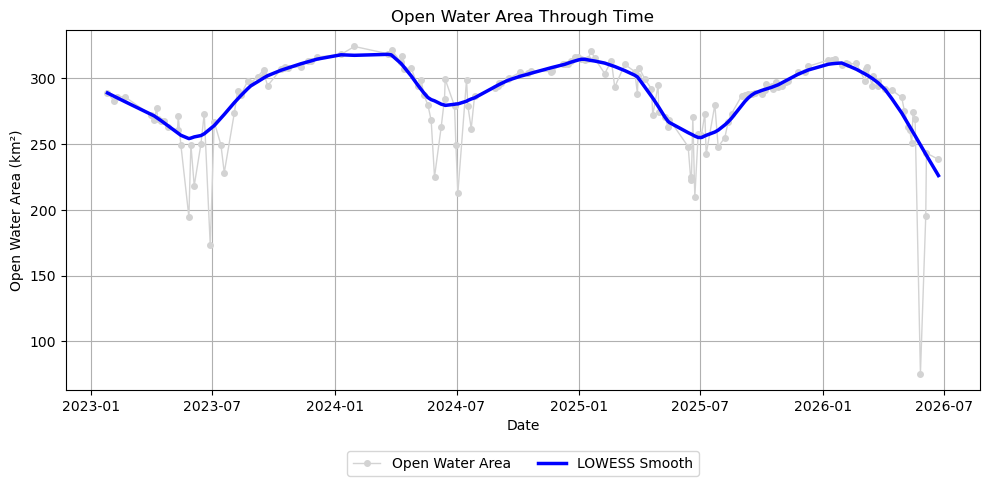

In [12]:
# Fit a LOWESS curve to the filtered time series

# Convert dates to numeric days since first observation.
# LOWESS operates on numeric x-values rather than datetime objects.
x = np.array([(d - dates_cloud_filtered[0]).days for d in dates_cloud_filtered])
y = np.array(water_km2_f)

# Apply LOWESS smoothing to the time series.
# frac = Fraction of neighboring observations used for each local regression.
# Larger values produce a smoother curve, while smaller values follow short-term variations more closely.
water_lowess = lowess(
    y,
    x,
    frac=0.1,
    return_sorted=False
)


plt.figure(figsize=(10, 5))


# Water area observations
plt.plot(
    dates_cloud_filtered,
    y,
    marker="o",
    markersize=4,
    linewidth=1,
    label="Open Water Area",
    color="lightgray"
)

# Overlay the LOWESS-smoothed trend
plt.plot(
    dates_cloud_filtered,
    water_lowess,
    linewidth=2.5,
    label="LOWESS Smooth",
    color="blue"
)

plt.xlabel("Date")
plt.ylabel("Open Water Area (km²)")
plt.title("Open Water Area Through Time")
plt.grid(True)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.tight_layout()
plt.show()

Even after filtering observations with excessive nodata and cloud cover, a few observations remain that fall well below the LOWESS-smoothed curve. These observations may arise from anomalous measurements or classification artifacts and can obscure the underlying temporal signal.

To identify these observations, we calculate the residuals between the observations and the LOWESS curve and use the **median absolute deviation (MAD)** to detect unusually large negative deviations. Because MAD is based on the median rather than the mean, the detection threshold is not unduly influenced by the very outliers we are trying to identify.

Removed 24 low outliers


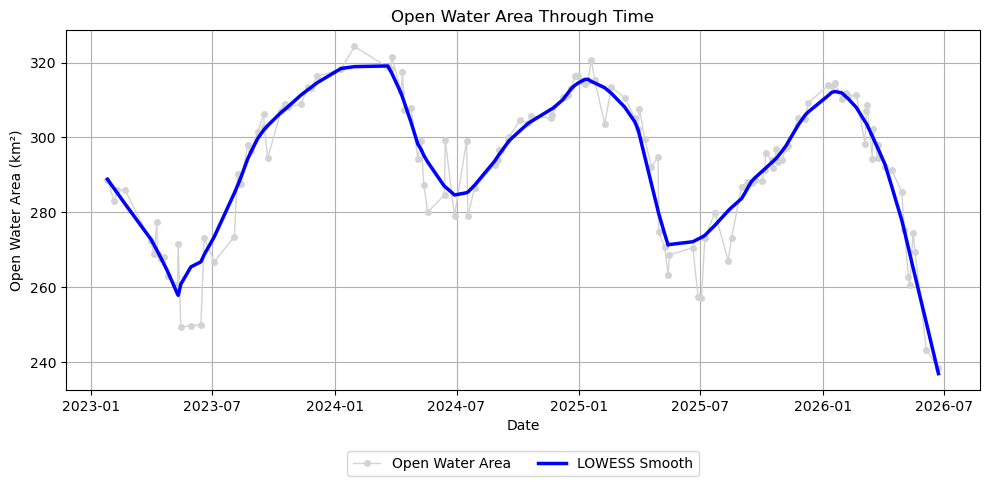

In [17]:
# Remove low outliers that deviate strongly from the LOWESS fit

# Calculate residuals between the observed water area and the LOWESS-smoothed curve.
residuals = y - water_lowess

# Calculate the median absolute deviation (MAD) of the residuals.
mad = np.median(np.abs(residuals - np.median(residuals)))  

# Retain observations that are not unusually far below the LOWESS curve.
# Here, low outliers are defined as observations more than 3 MAD below the smoothed curve.
MAD_THRESHOLD = 3
mask = residuals > (-MAD_THRESHOLD * mad)

dates_clean = np.array(dates_cloud_filtered)[mask]
x_clean = x[mask]
y_clean = y[mask]

# Recompute LOWESS using cleaned data
water_lowess_clean = lowess(
    y_clean,
    x_clean,
    frac=0.1,
    return_sorted=False
)

print(f"Removed {np.sum(~mask)} low outliers")


plt.figure(figsize=(10, 5))

# Water area observations
plt.plot(
    dates_clean,
    y_clean,
    marker="o",
    markersize=4,
    linewidth=1,
    label="Open Water Area",
    color="lightgray"
)

# Overlay the LOWESS-smoothed trend
plt.plot(
    dates_clean,
    water_lowess_clean,
    linewidth=2.5,
    label="LOWESS Smooth",
    color="blue"
)

plt.xlabel("Date")
plt.ylabel("Open Water Area (km²)")
plt.title("Open Water Area Through Time")
plt.grid(True)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.tight_layout()
plt.show()

Finally, we fit a linear regression model to estimate the long-term rate of change in surface water extent.

Because surface water exhibits a strong seasonal cycle, it is good practice to fit the linear trend over a time period that begins and ends at approximately the same time of year. Doing so minimizes the influence of seasonal variability on the estimated long-term trend, allowing the regression to better represent long-term changes in surface water extent.

In [18]:
# Fit a linear regression model to the cleaned time series

# Define the date range used for estimating the long-term trend.
# The start and end dates should ideally span an integer number of years
# so that the regression is less influenced by seasonal variability.
TREND_START_DATE = "2023-06-01"
TREND_END_DATE = "2026-05-31"

dates_clean = np.array(dates_clean)

trend_start_date = datetime.strptime(TREND_START_DATE, "%Y-%m-%d").date()
trend_end_date = datetime.strptime(TREND_END_DATE, "%Y-%m-%d").date()

# Select observations within the trend analysis period
trend_mask = (dates_clean >= trend_start_date) & (dates_clean <= trend_end_date)

x_trend = x_clean[trend_mask]
y_trend = y_clean[trend_mask]

# Fit a first-order (linear) regression model
slope, intercept = np.polyfit(x_trend, y_trend, 1)

# Evaluate the fitted trend line
water_trend_clean = slope * x_trend + intercept

print(f"Slope: {slope * 365.25:.2f} km²/year")

Slope: -3.10 km²/year


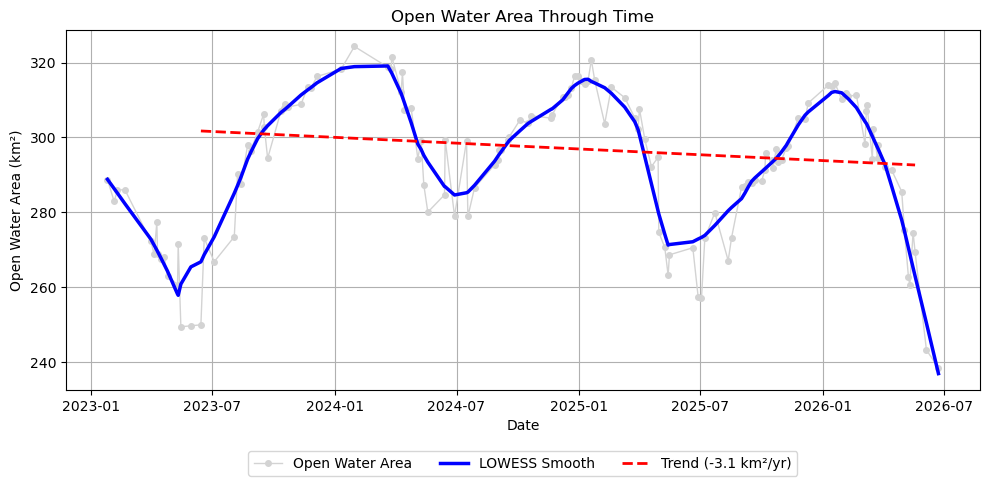

In [19]:
# Plot open water area with seasonal and long-term trend lines

plt.figure(figsize=(10, 5))

# Water area observations
plt.plot(
    dates_clean,
    y_clean,
    marker="o",
    markersize=4,
    linewidth=1,
    label="Open Water Area",
    color="lightgray"
)

# Overlay the LOWESS-smoothed trend
plt.plot(
    dates_clean,
    water_lowess_clean,
    linewidth=2.5,
    label="LOWESS Smooth",
    color="blue"
)

# Overlay the linear trend line for the selected trend analysis period
plt.plot(
    dates_clean[trend_mask],
    water_trend_clean,
    linewidth=2,
    linestyle="--",
    color="red",
    label=f"Trend ({slope * 365.25:.1f} km²/yr)"
)

plt.xlabel("Date")
plt.ylabel("Open Water Area (km²)")
plt.title("Open Water Area Through Time")
plt.grid(True)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3)
plt.tight_layout()
plt.show()

## Conclusions

Using OPERA DSWx-HLS observations from the Earthdata GIS (EGIS) Image Service, we constructed a quality-filtered time series of Lake Mead's open water extent and evaluated how it changed over time. After removing observations with excessive nodata, cloud cover, and statistical outliers, we applied LOWESS smoothing to visualize seasonal variability and fit a linear regression model to estimate the long-term trend.

For the 3-year trend analysis period of `2023-06-01` through `2026-05-31`, the fitted linear regression indicates a change in open water extent of **-3.1 km² per year**. A negative slope indicates a long-term decrease in surface water extent, while a positive slope indicates an increase. This value should be interpreted within the context of the selected analysis period and reflects the average rate of change over that interval.

Although this notebook uses Lake Mead as an example, the same workflow can be applied to any region covered by OPERA DSWx-HLS. By modifying the area of interest, date range, and filtering parameters, users can investigate seasonal and long-term changes in surface water for lakes, reservoirs, rivers, wetlands, and other hydrologic systems around the world.